In [2]:
!wget https://github.com/kairess/toy-datasets/raw/master/dog-inflammation.zip
!unzip -q dog-inflammation.zip

--2025-05-13 12:12:21--  https://github.com/kairess/toy-datasets/raw/master/dog-inflammation.zip
github.com (github.com) 해석 중... 20.200.245.247
다음으로 연결 중: github.com (github.com)|20.200.245.247|:443... 연결했습니다.
HTTP 요청을 보냈습니다. 응답 기다리는 중... 302 Found
위치: https://raw.githubusercontent.com/kairess/toy-datasets/master/dog-inflammation.zip [따라감]
--2025-05-13 12:12:22--  https://raw.githubusercontent.com/kairess/toy-datasets/master/dog-inflammation.zip
raw.githubusercontent.com (raw.githubusercontent.com) 해석 중... 185.199.109.133, 185.199.111.133, 185.199.108.133, ...
다음으로 연결 중: raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... 연결했습니다.
HTTP 요청을 보냈습니다. 응답 기다리는 중... 200 OK
길이: 4592449 (4.4M) [application/zip]
저장 위치: `dog-inflammation.zip'

dog-inflammation.zi 100%[===================>]   4.38M  --.-KB/s    /  0.1s    

2025-05-13 12:12:25 (30.7 MB/s) - `dog-inflammation.zip' 저장함 [4592449/4592449]



In [2]:
#dataloader
from fastai.vision.all import *

path = 'dog-inflammation'

block = DataBlock(
    blocks = (ImageBlock, CategoryBlock), # Input, Output
    get_items = get_image_files, # PIL
    get_y = parent_label, # 폴더
)

loader = block.dataloaders(path)

loader.show_batch()

ModuleNotFoundError: No module named 'requests'

In [2]:
# train # 전이 학습 - 파인 튜닝
learn = vision_learner(loader, resnet18, metrics=accuracy)
learn.fine_tune(epochs = 3)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/kimdohyeon/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:01<00:00, 44.4MB/s]


epoch,train_loss,valid_loss,accuracy,time
0,0.657476,0.170545,0.966667,00:06


epoch,train_loss,valid_loss,accuracy,time
0,0.083250,0.115786,0.983333,00:03
1,0.055882,0.144900,0.991667,00:02
2,0.039085,0.114578,0.991667,00:02


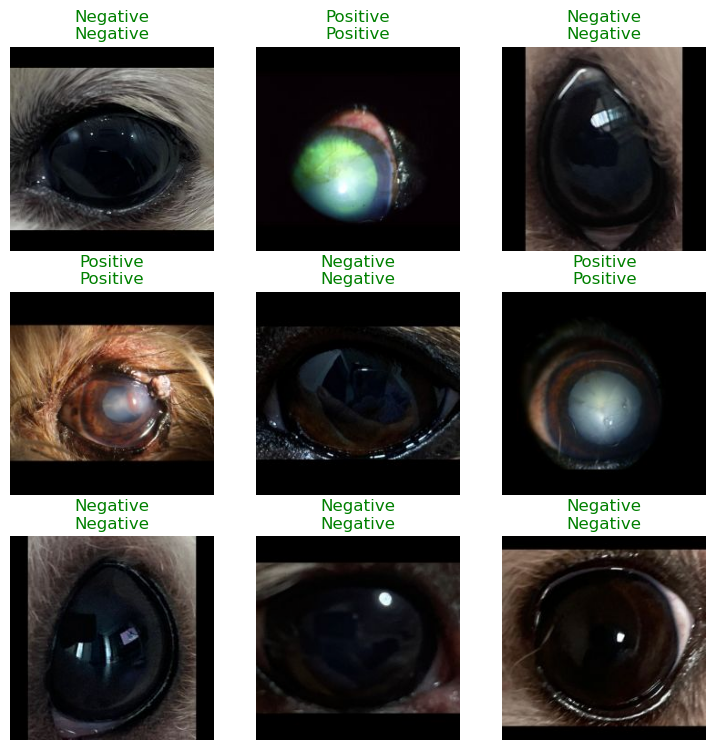

In [3]:
# test result
learn.show_results() # 위에가 정답

torch.Size([1, 3, 224, 224]) torch.Size([1, 3, 224, 224])


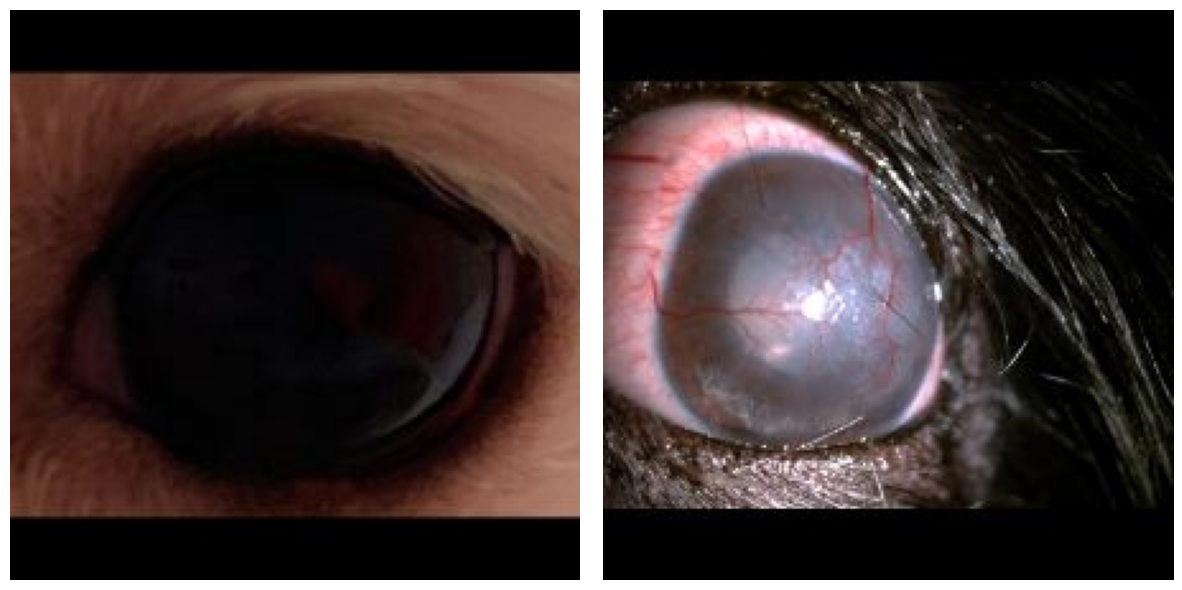

In [5]:
# GradCAM
neg_path = '/Users/kimdohyeon/건양대학교병원_바이오헬스/Biomedical_AI_Train/Medical_practice/0513/dog-inflammation/Negative/D0_03f7e7c0-60a5-11ec-8402-0a7404972c70.jpg'
pos_path = '/Users/kimdohyeon/건양대학교병원_바이오헬스/Biomedical_AI_Train/Medical_practice/0513/dog-inflammation/Positive/D0_02fa7d26-60a5-11ec-8402-0a7404972c70.jpg'

test_loader = loader.test_dl([neg_path, pos_path]) # 전처리

neg_x, pos_x = next(iter(test_loader))[0]

neg_x = neg_x.unsqueeze(0)
pos_x = pos_x.unsqueeze(0)

print(neg_x.shape, pos_x.shape)

neg_img = Image.open(neg_path)
pos_img = Image.open(pos_path)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(neg_img)
ax[0].axis('off')
ax[1].imshow(pos_img)
ax[1].axis('off')
plt.tight_layout()
plt.show()

In [6]:
class Hook():
    def __init__(self, m):
        self.hook = m.register_forward_hook(self.hook_func)
    def hook_func(self, m, i, o): # 모듈, 입력, 출력
        self.stored = o.detach().clone()
    def __enter__(self, *args):
        return self
    def __exit__(self, *args):
        self.hook.remove()

class HookBwd():
    def __init__(self, m):
        self.hook = m.register_backward_hook(self.hook_func)
    def hook_func(self, m, gi, go):
        self.stored = go[0].detach().clone()
    def __enter__(self, *args):
        return self
    def __exit__(self, *args):
        self.hook.remove()

In [7]:
def get_gradcam(x, location=-1): # 어느 레이어에서 뽑아낼껀지
    with HookBwd(learn.model[0][location]) as hookg:
        with Hook(learn.model[0][location]) as hook:
            output = learn.model.eval()(x.cuda())
            idx = torch.argmax(output)
            act = hook.stored
        output[0, idx].backward()
        grad = hookg.stored

    w = grad[0].mean(dim=[1, 2], keepdim=True)
    heatmap = (w * act[0]).sum(0).detach().cpu()

    return heatmap

heatmap = get_gradcam(pos_x, location=-2)

print(heatmap.shape)
plt.imshow(heatmap, cmap='jet')
plt.show()

AssertionError: Torch not compiled with CUDA enabled

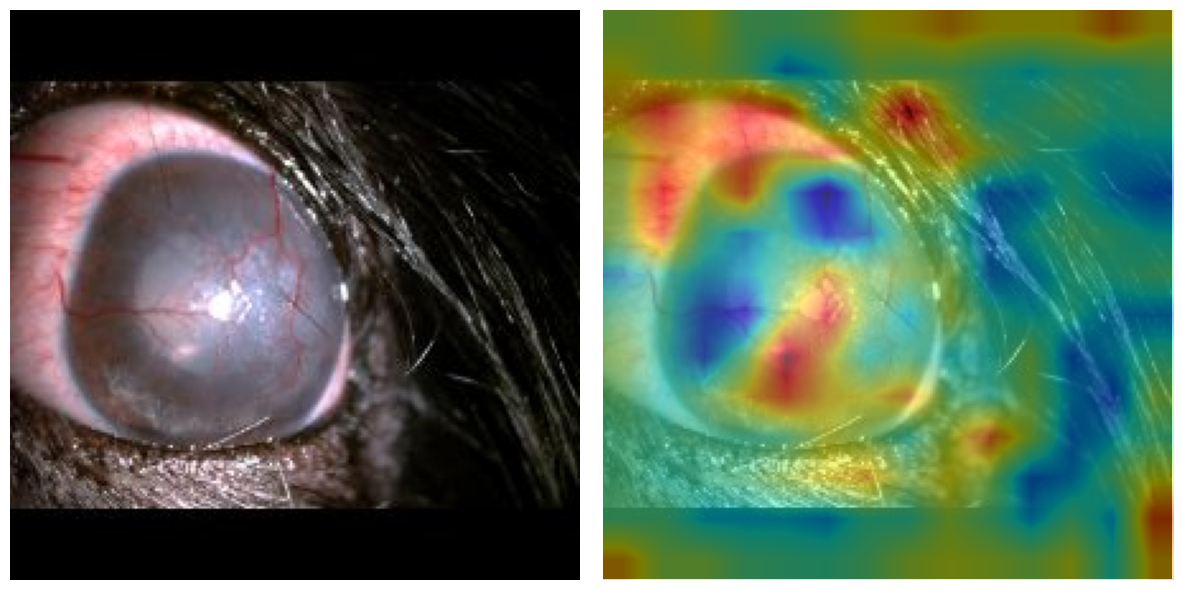

In [ ]:
# Positive
img = Image.open(pos_path)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(img)
ax[0].axis('off')
ax[1].imshow(img)
ax[1].imshow(heatmap.cpu(), alpha=0.5, extent=(0,224,224,0),
              interpolation='bilinear', cmap='jet')
ax[1].axis('off')
plt.tight_layout()
plt.show()

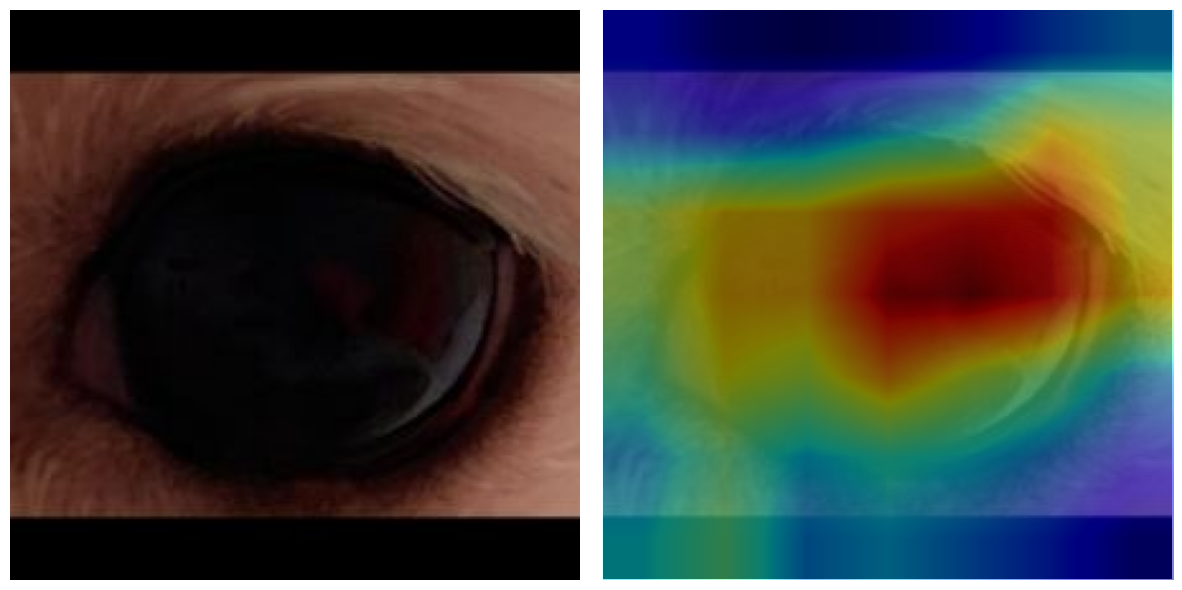

In [ ]:
# Negative
heatmap = get_gradcam(neg_x, location=-1)
img = Image.open(neg_path)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(img)
ax[0].axis('off')
ax[1].imshow(img)
ax[1].imshow(heatmap.cpu(), alpha=0.5, extent=(0,224,224,0),
              interpolation='bilinear', cmap='jet')
ax[1].axis('off')
plt.tight_layout()
plt.show()